# 01 — Audio waveform

In this notebook we explore audio signals in the time domain.

We will move from a simple synthetic signal to a real audio example from the ESC-50 dataset.

The main goals are to understand:

1. What a digital audio signal is.
2. The difference between sampling rate and sound frequency.
3. How a pure tone is represented as a waveform.
4. How to load, listen to, and visualize real audio.
5. Why the waveform is useful, but also limited for describing complex sounds.


## Imports


In [62]:
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio, display


## Project paths

The notebook can be run either from the project root or from the `notebooks/` folder.
The following cell defines the project root and the path to the prepared ESC-50 subset metadata.


In [63]:
PROJECT_ROOT = Path.cwd()

# If the notebook is launched from the notebooks folder,
# move one level up to the project root.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SUBSET_METADATA = PROJECT_ROOT / "data" / "processed" / "esc50_subset" / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA)
print("Metadata exists:", SUBSET_METADATA.exists())


Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Metadata exists: True


## Load the ESC-50 subset metadata

The dataset audit was performed in `00_dataset_audit.ipynb`.

Here we only load the metadata needed to select and visualize audio examples.


In [64]:
metadata = pd.read_csv(SUBSET_METADATA)

print("Number of audio files:", len(metadata))
print("Number of classes:", metadata["category"].nunique())

metadata.head()


Number of audio files: 80
Number of classes: 8


,filename,fold,target,category,esc10,src_file,take,subset_audio_path
0,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,data/processed/esc50_subset/audio/1-100038-A-1...
1,1-34495-A-14.wav,1,14,chirping_birds,False,34495,A,data/processed/esc50_subset/audio/1-34495-A-14...
2,1-34497-A-14.wav,1,14,chirping_birds,False,34497,A,data/processed/esc50_subset/audio/1-34497-A-14...
3,1-38559-A-14.wav,1,14,chirping_birds,False,38559,A,data/processed/esc50_subset/audio/1-38559-A-14...
4,1-38560-A-14.wav,1,14,chirping_birds,False,38560,A,data/processed/esc50_subset/audio/1-38560-A-14...


## What is a digital audio signal?

Sound in the physical world is a variation of air pressure over time.  
This is a continuous-time phenomenon: in principle, the pressure changes at every instant.

However, a computer cannot store a continuous signal directly.  
Instead, the audio signal is represented as a sequence of discrete samples.

A digital audio signal can be written as:

$$
x[n], \quad n = 0, 1, 2, \ldots, N-1
$$

where:

- $x[n]$ is the amplitude of the signal at sample index $n$,
- $n$ is the sample number,
- $N$ is the total number of samples.

The sampling rate, usually denoted as $f_s$, indicates how many samples are taken per second.

For example, if:

$$
f_s = 44100 \text{ Hz}
$$

then the signal contains 44,100 samples per second.

The time associated with sample $n$ is:

$$
t_n = \frac{n}{f_s}
$$

Therefore, the duration of a digital audio signal is:

$$
T = \frac{N}{f_s}
$$

In Python, when we load an audio file using `librosa`, we usually obtain:

```python
y, sr = librosa.load(audio_path)
```

where:

- `y` is the audio signal as a NumPy array,
- `sr` is the sampling rate,
- `len(y)` is the number of samples,
- `len(y) / sr` is the duration in seconds.

In short:

```text
continuous physical sound → sampling process → digital audio signal → numerical array
```


## Sampling rate versus sound frequency

The sampling rate $f_s$ and the sound frequency $f$ are different concepts.

The **sampling rate** $f_s$ tells us how many samples per second are used to represent the signal digitally.

The **sound frequency** $f$ tells us how many oscillations per second are present in the sound itself.

For example, a pure tone of frequency:

$$
f = 5 \text{ Hz}
$$

completes 5 cycles in one second.

If this tone is sampled at:

$$
f_s = 1000 \text{ Hz}
$$

then the computer stores 1000 amplitude values during that second.

A pure sinusoidal tone in continuous time can be written as:

$$
x(t) = A \sin(2 \pi f t)
$$

After sampling, the digital signal becomes:

$$
x[n] = A \sin\left(2 \pi f \frac{n}{f_s}\right)
$$

where:

- $A$ is the amplitude,
- $f$ is the sound frequency,
- $f_s$ is the sampling rate,
- $n$ is the sample index.

In short:

```text
sampling rate → how often we measure the signal
sound frequency → how fast the sound oscillates
```


## Create a simple pure tone

We first create a low-frequency synthetic tone.  
A 5 Hz tone is not useful for listening, but it is very useful for visualizing how oscillations appear in the time-domain waveform.


In [65]:
sampling_rate = 1000  # samples per second
sound_frequency = 5   # oscillations per second
duration_s = 1.0
amplitude = 1.0

t = np.arange(0, duration_s, 1 / sampling_rate)
x = amplitude * np.sin(2 * np.pi * sound_frequency * t)

print("Sampling rate:", sampling_rate, "Hz")
print("Sound frequency:", sound_frequency, "Hz")
print("Number of samples:", len(x))
print("Duration:", len(x) / sampling_rate, "seconds")
print("First 10 samples:")
print(x[:10])


Sampling rate: 1000 Hz
Sound frequency: 5 Hz
Number of samples: 1000
Duration: 1.0 seconds
First 10 samples:
[0.         0.03141076 0.06279052 0.09410831 0.12533323 0.15643447
 0.18738131 0.21814324 0.24868989 0.27899111]


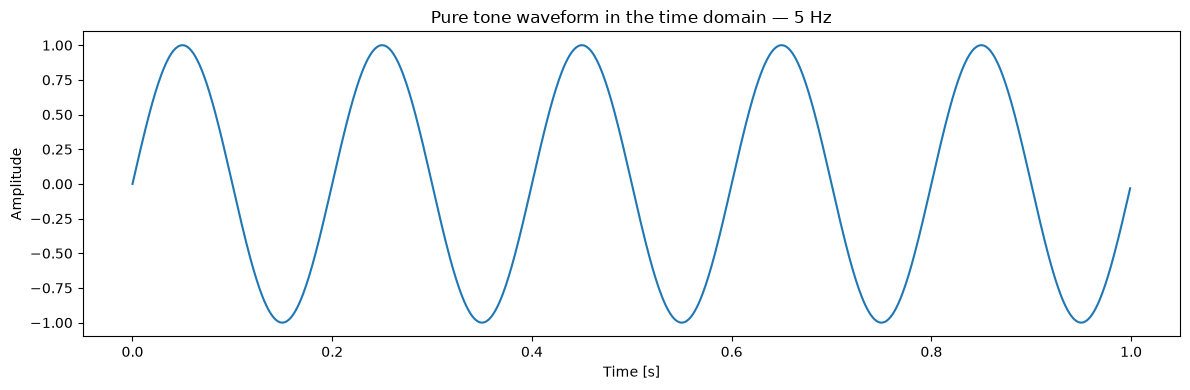

In [66]:
plt.figure(figsize=(12, 4))
plt.plot(t, x)
plt.title("Pure tone waveform in the time domain — 5 Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


## Compare pure tones with different frequencies

A higher sound frequency means more oscillations in the same time interval.


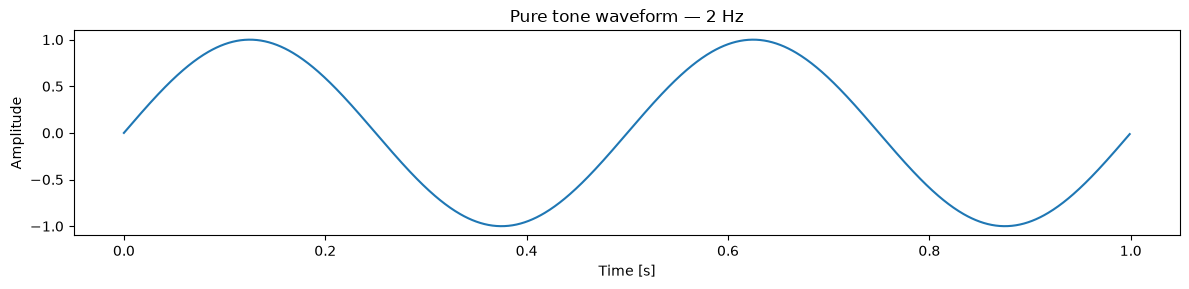

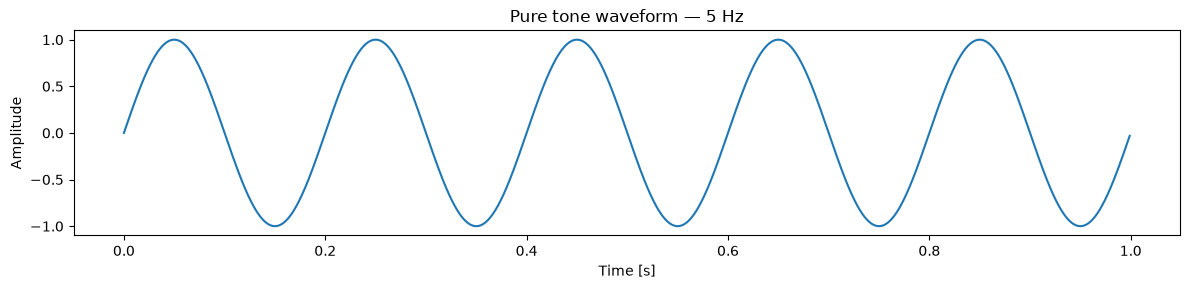

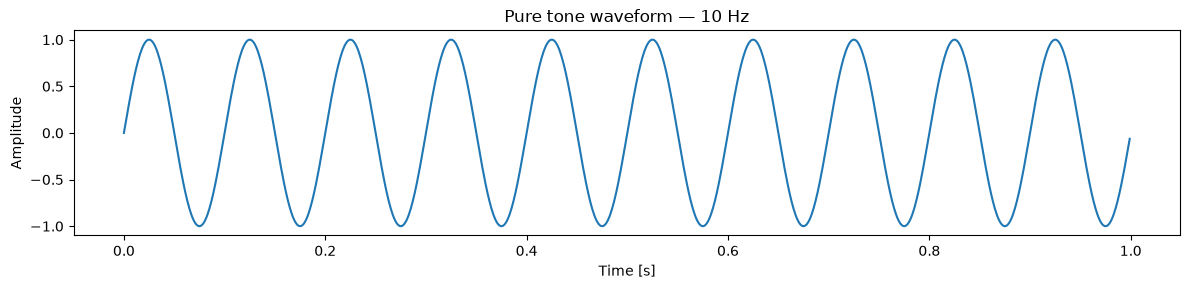

In [67]:
frequencies = [2, 5, 10]

for sound_frequency in frequencies:
    x_frequency = np.sin(2 * np.pi * sound_frequency * t)

    plt.figure(figsize=(12, 3))
    plt.plot(t, x_frequency)
    plt.title(f"Pure tone waveform — {sound_frequency} Hz")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


## Listen to an audible pure tone

The 5 Hz tone is below the usual human audible range.  
To listen to a pure tone, we use a higher frequency.

Here we synthesize a 440 Hz tone, which corresponds approximately to the musical pitch A4.


In [68]:
sampling_rate = 22050   # samples per second
sound_frequency = 440   # audible pure tone in Hz
duration_s = 2.0
amplitude = 0.3         # lower amplitude to avoid loud playback

t_audio = np.arange(0, duration_s, 1 / sampling_rate)
pure_tone = amplitude * np.sin(2 * np.pi * sound_frequency * t_audio)

print("Sampling rate:", sampling_rate, "Hz")
print("Sound frequency:", sound_frequency, "Hz")
print("Duration:", duration_s, "seconds")
print("Number of samples:", len(pure_tone))

display(Audio(pure_tone, rate=sampling_rate))


Sampling rate: 22050 Hz
Sound frequency: 440 Hz
Duration: 2.0 seconds
Number of samples: 44100


## Zoom into the audible tone waveform

An audible-frequency tone oscillates so fast that we need to zoom in to see individual cycles.


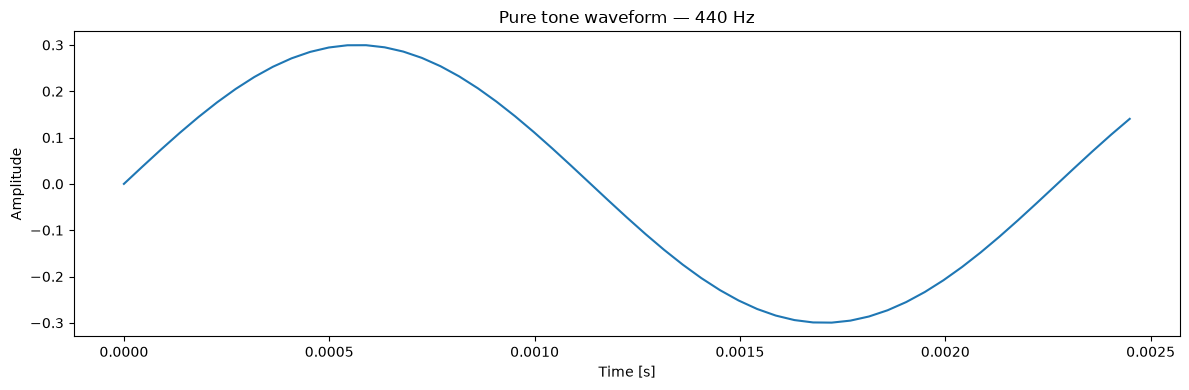

In [69]:
time_window = 0.0025  # seconds
samples_to_plot = int(time_window * sampling_rate)

plt.figure(figsize=(12, 4))
plt.plot(t_audio[:samples_to_plot], pure_tone[:samples_to_plot])
plt.title("Pure tone waveform — 440 Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


## Select a real audio example

Now we move from a synthetic signal to a real environmental sound from the ESC-50 subset.


In [70]:
selected_category = "sneezing" # "rain"

example = metadata[metadata["category"] == selected_category].iloc[0]

example


filename                                              1-26143-A-21.wav
fold                                                                 1
target                                                              21
category                                                      sneezing
esc10                                                             True
src_file                                                         26143
take                                                                 A
subset_audio_path    data/processed/esc50_subset/audio/1-26143-A-21...
Name: 70, dtype: object

## Load the real audio waveform

We use `librosa.load` with `sr=None` to preserve the original sampling rate of the audio file.


In [71]:
audio_path = PROJECT_ROOT / example["subset_audio_path"]

y, sr = librosa.load(audio_path, sr=None, mono=True)
duration = librosa.get_duration(y=y, sr=sr)

print("Audio path:", audio_path)
print("Sampling rate:", sr, "Hz")
print("Number of samples:", len(y))
print("Duration:", duration, "seconds")
print("Minimum amplitude:", y.min())
print("Maximum amplitude:", y.max())


Audio path: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/audio/1-26143-A-21.wav
Sampling rate: 44100 Hz
Number of samples: 220500
Duration: 5.0 seconds
Minimum amplitude: -0.8491516
Maximum amplitude: 0.94625854


## Listen to the real audio example


In [72]:
display(Audio(y, rate=sr))


## Plot the real audio waveform

The waveform shows how the amplitude of the audio signal changes over time.


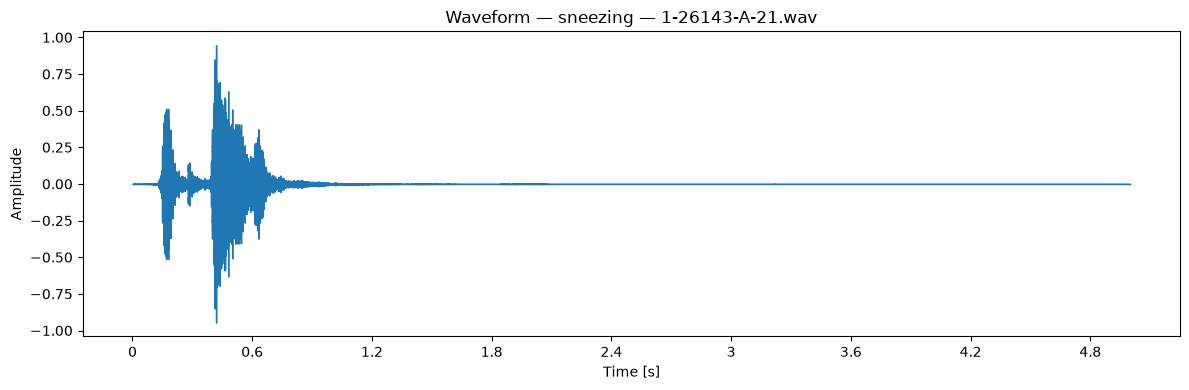

In [73]:
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform — {example['category']} — {example['filename']}")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


## Compare waveforms from different classes

Different sounds may have different time-domain structures.  
Some are impulsive, some are more continuous, and others show repeated events.


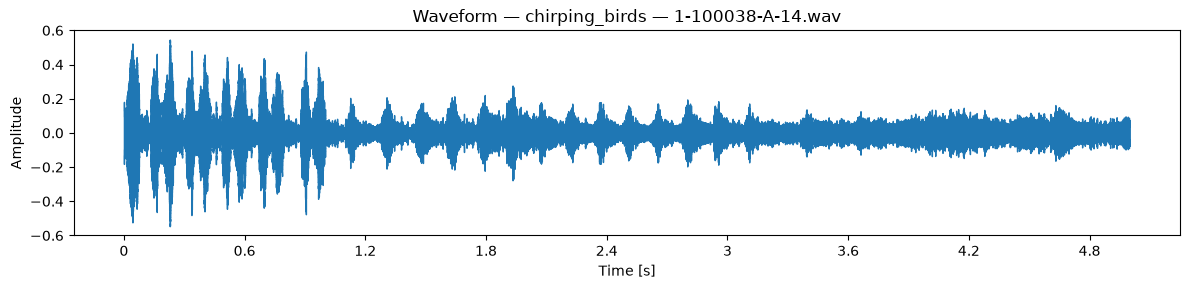

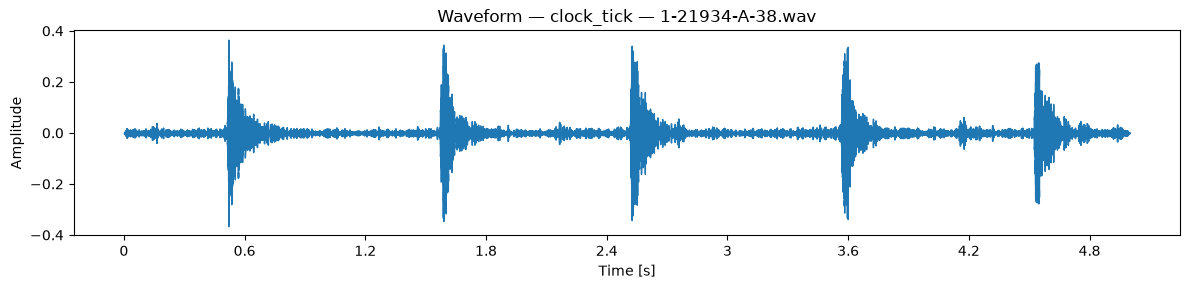

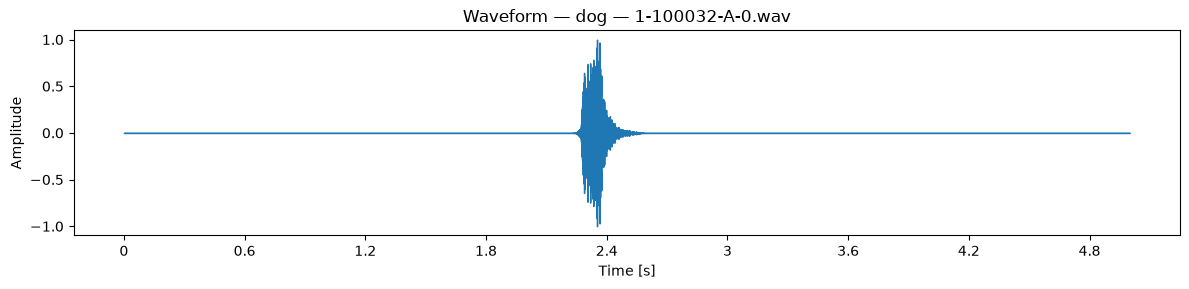

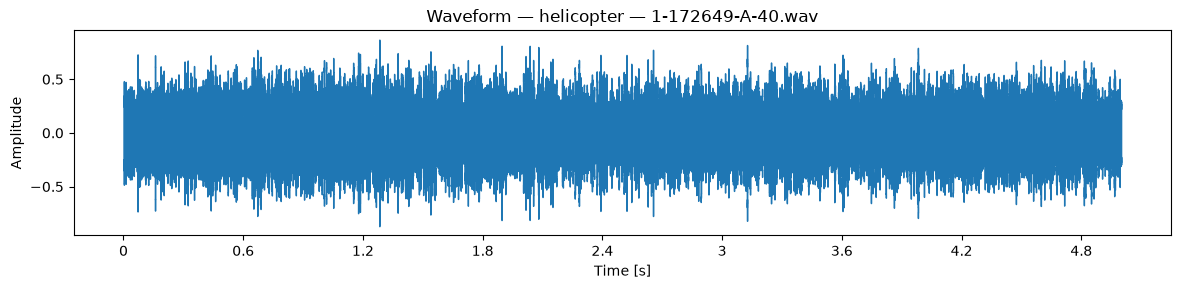

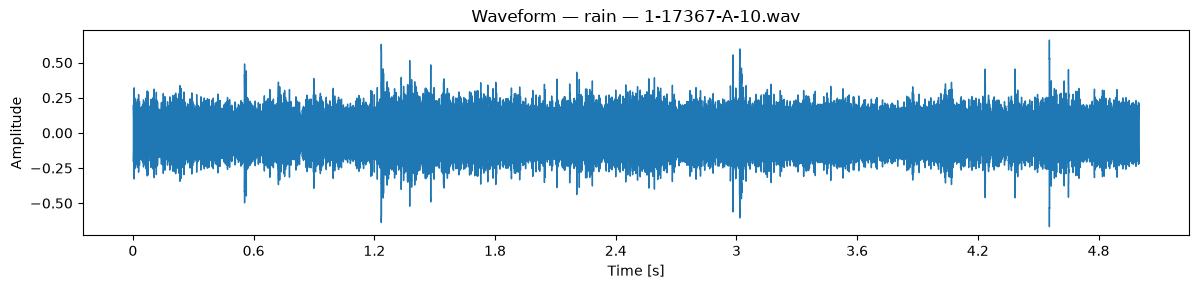

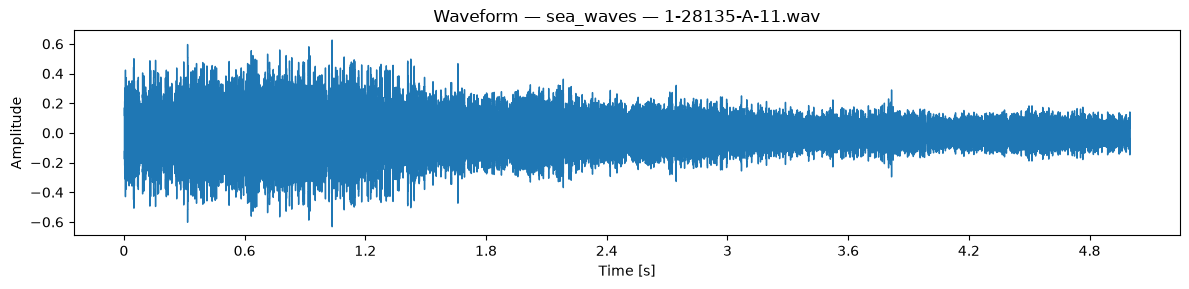

In [74]:
selected_categories = [
    "chirping_birds",
    "clock_tick",
    "dog",
    "helicopter",
    "rain",
    "sea_waves",
]

for category in selected_categories:
    row = metadata[metadata["category"] == category].iloc[0]
    audio_path = PROJECT_ROOT / row["subset_audio_path"]

    y_example, sr_example = librosa.load(audio_path, sr=None, mono=True)

    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(y_example, sr=sr_example)
    plt.title(f"Waveform — {category} — {row['filename']}")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()


## Discussion questions

1. Which sounds look more impulsive in the time domain?
2. Which sounds look more continuous or stationary?
3. Can we distinguish all classes using only the waveform?
4. What information is difficult to observe directly in the waveform?
5. Why might we need a frequency-domain or time-frequency representation?
